### fitting

In [194]:
NT = 96
def pion_model_single(t,A0,E0):
    return A0*np.exp(-E0*t)

def pion_model(t, A0, E0):
    return (A0*np.exp(-E0*t) + A0*np.exp(-(NT-t)*E0))

In [203]:
def c2pt_fit_one_traj(data, tmin, tmax):
    t_fit = np.arange(tmin,tmax)

    data_range = data[tmin:tmax]
    p0 = [data_range[0],0.1]

    popt, pcov = curve_fit(pion_model_single, t_fit, data_range, p0, maxfev=10000)

    A0, E0 = popt
    E0_err = np.sqrt(pcov[1,1])

    print(f"Single trajectory exponential fit: E0: {E0} +/- {E0_err}")

### analysis

In [170]:
import qlat as q
import numpy as np
import matplotlib.pyplot as plt
import jackknife
from scipy.optimize import curve_fit

In [125]:
dst_test = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-gt-test/traj-1525/meson_corr_psnk_psrc_psel.lat"
test_arr =  q.load_lat_data(dst_test).to_numpy()
print(test_arr.shape)

(5, 96)


In [144]:
dst2 = "/home/jhildebrand28/ktopipi/results/48I/auto-contract-gt-test/traj-1505/meson_corr_psnk_psrc_psel.lat"
arr2 = q.load_lat_data(dst2).to_numpy()
print(arr2.shape)

(13, 96)


In [211]:
print(np.average(np.real(arr2[1]))/np.average(np.imag(arr2[1])))

65.14725666725424


In [219]:
test_arr[2,:24]

array([3.65774732e+10+7.08962774e+09j, 2.26980585e+12+1.82952683e+09j,
       1.10588774e+11-3.53021823e+09j, 9.18825573e+10-4.27707944e+07j,
       4.04891076e+10+5.03752226e+09j, 7.20925106e+10+7.95464580e+09j,
       4.95803738e+10+1.29621936e+09j, 9.27791422e+10-4.07677431e+09j,
       5.61232267e+10-3.15755671e+08j, 9.47844534e+10+4.12665588e+09j,
       8.59441205e+10-6.42357430e+08j, 4.19419181e+10+4.58090429e+09j,
       5.45726145e+10+2.68562926e+09j, 3.44459561e+10+3.19810128e+09j,
       4.27657269e+10+7.40903535e+08j, 2.74834928e+10-6.52701518e+08j,
       1.48353538e+10+1.38816070e+08j, 1.86359785e+10-9.58678649e+08j,
       2.87439395e+10+3.68268033e+09j, 3.30712961e+10-1.91675464e+09j,
       4.40786544e+10-1.12945740e+09j, 1.06325271e+10-6.55977906e+08j,
       6.72564467e+09+8.54868688e+08j, 1.01906090e+10+2.06351155e+09j])

In [ ]:
test_arr

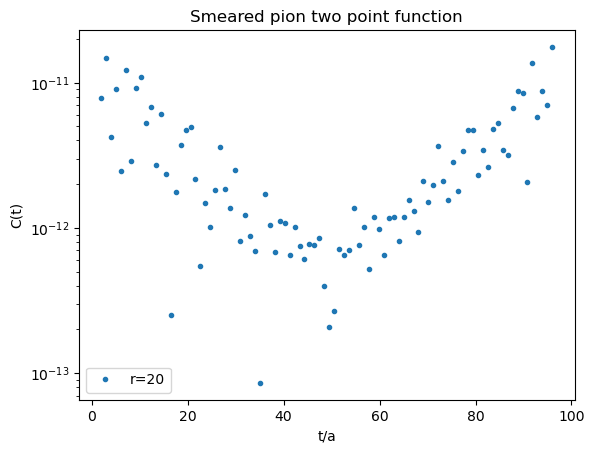

In [215]:
t = np.linspace(2,96,92)
fig, ax = plt.subplots()
ax.plot(t, arr2[1,2:94]/arr2[0,2:94],marker='.',ls='', label='r=2')
ax.plot(t, test_arr[1][2:94]/test_arr[0][2:94], marker='.', ls='',label='r=5')
ax.plot(t, test_arr[2][2:94]/test_arr[0][2:94], marker='.', ls='',label='r=10')
ax.plot(t, test_arr[3][2:94]/test_arr[0][2:94], marker='.', ls='',label='r=20')
ax.set_xlabel('t/a')
ax.set_ylabel('C(t)')
ax.set_yscale('log')
ax.set_title('Smeared pion two point function')
ax.legend();

/nix/store/gvn57gib1fg73fcqd412nvqq85knjp0i-python3-3.13.9-env/lib/python3.13/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/nix/store/gvn57gib1fg73fcqd412nvqq85knjp0i-python3-3.13.9-env/lib/python3.13/site-packages/matplotlib/cbook.py:1355: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


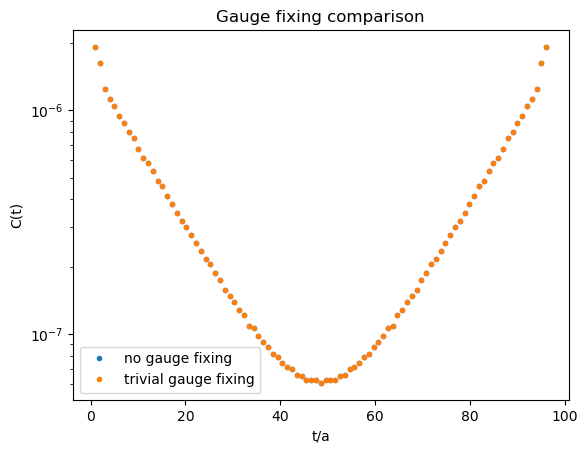

In [163]:
t2 = np.linspace(1,96,95)
fig, ax = plt.subplots()
ax.plot(t2, arr2[2,1:]/arr2[0,1:],marker='.',ls='', label='no gauge fixing')
ax.plot(t2, arr2[3,1:]/arr2[0,1:],marker='.',ls='', label='trivial gauge fixing')
ax.set_xlabel('t/a')
ax.set_ylabel('C(t)')
ax.set_yscale('log')
ax.set_title('Gauge fixing comparison')
ax.legend()

In [204]:
c2pt_fit_one_traj(arr2[2].real,10,30)

Single trajectory exponential fit: E0: 0.08169676761280294 +/- 0.0009549607109287766


In [205]:
c2pt_fit_one_traj(arr2[1].real,10,30) #r=2
c2pt_fit_one_traj(test_arr[1].real,10,30) #r=5
c2pt_fit_one_traj(test_arr[2].real,10,30) #r=10
c2pt_fit_one_traj(test_arr[3].real,10,30) #r=20

Single trajectory exponential fit: E0: 0.11309740984870645 +/- 0.022535641069255
Single trajectory exponential fit: E0: 0.12595533447040463 +/- 0.02416651707043567
Single trajectory exponential fit: E0: 0.11118905194280597 +/- 0.021586599134493803
Single trajectory exponential fit: E0: 0.11412771203756274 +/- 0.029426343490652325
